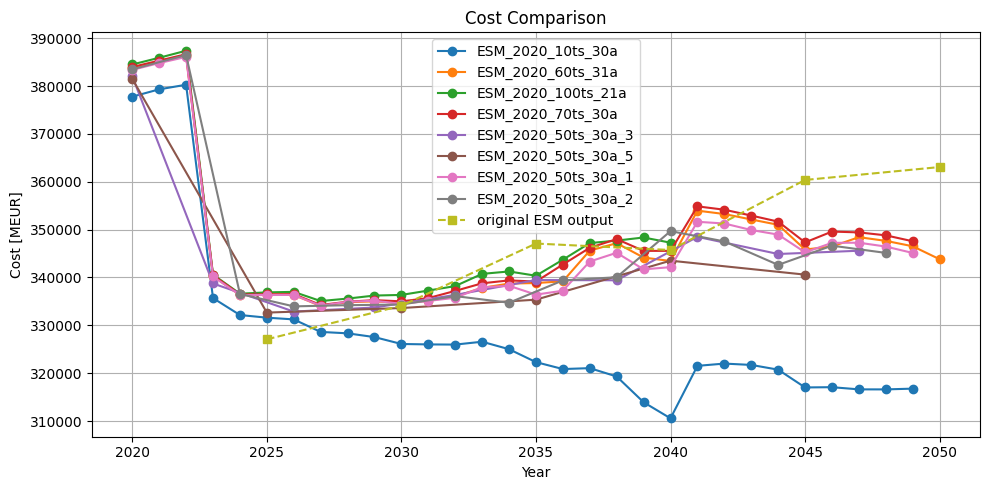

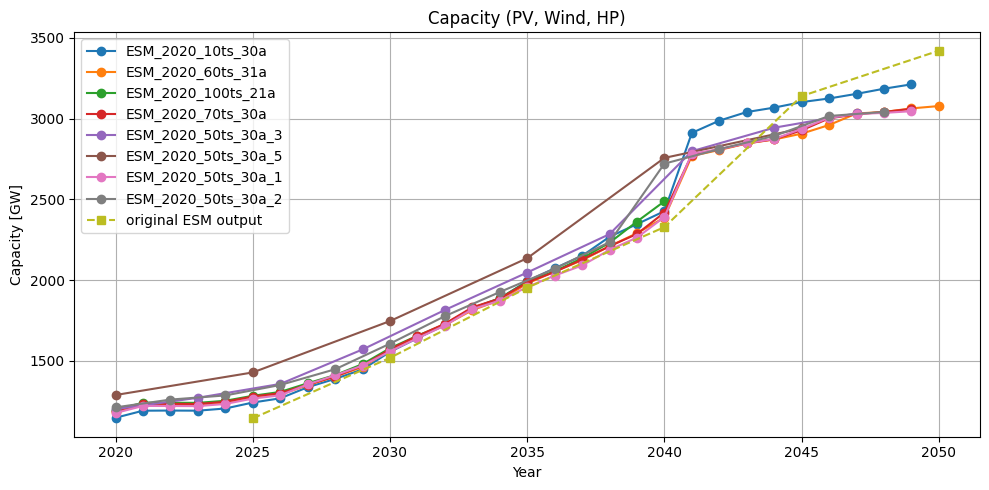

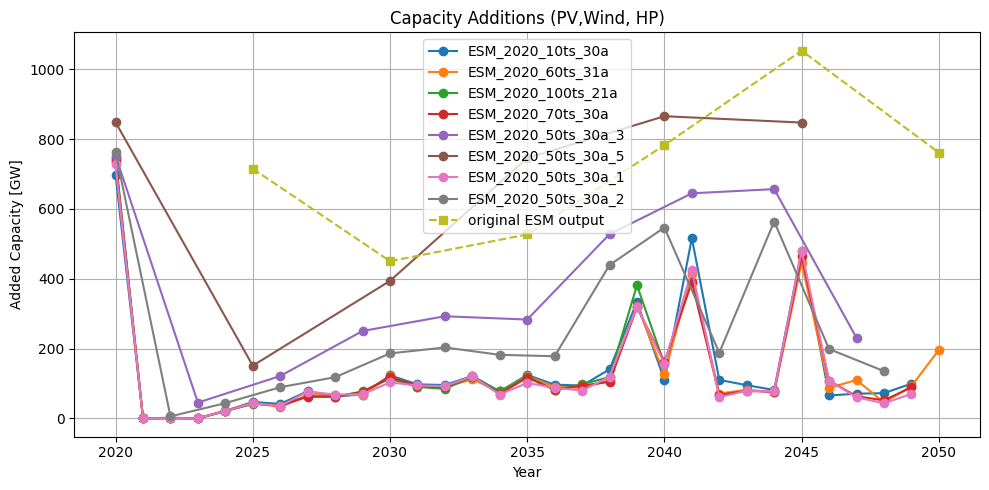

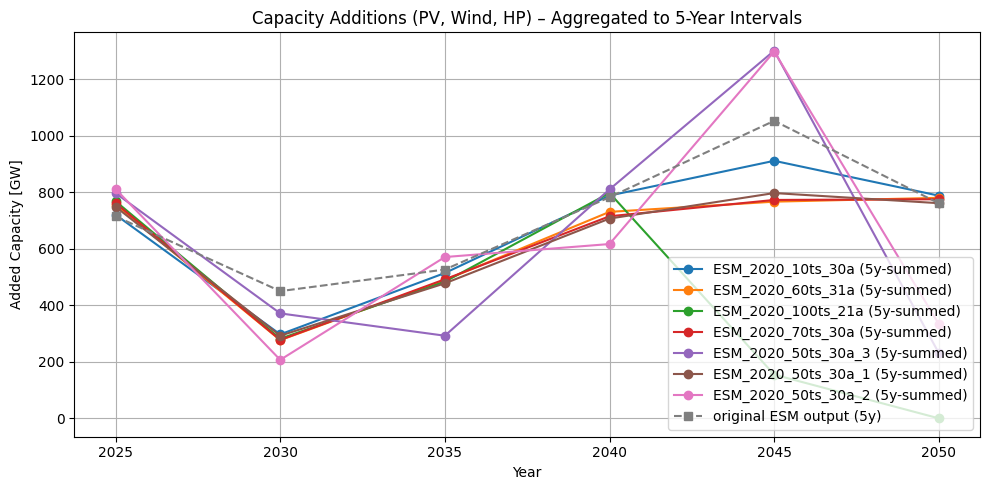

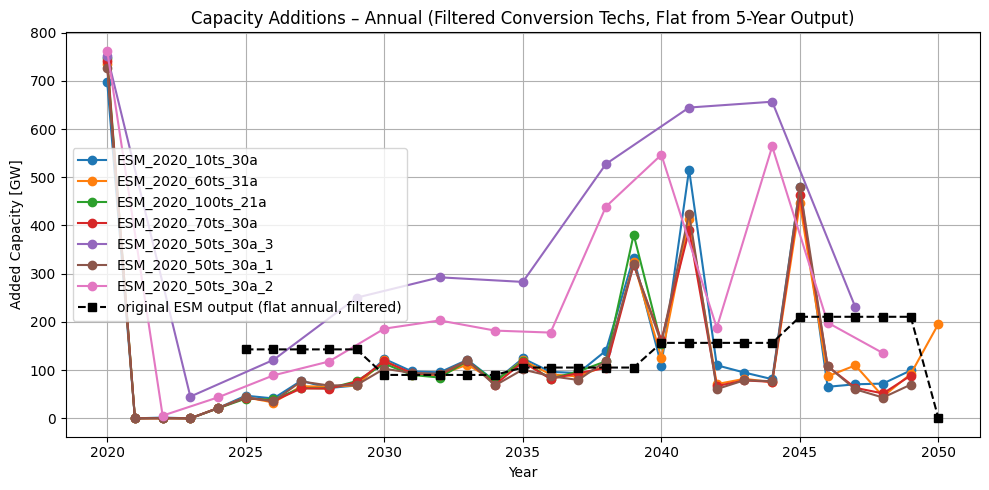

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
input_datasets = [
    '2020_10ts_30a',
    'energy_transition_example_input7',
    '2020_100ts_21a',
    '2020_70ts_30a',
    '2020_50ts_30a_3',
    '2020_50ts_30a_5',
    '2020_50ts_30a_1',
    '2020_50ts_30a_2',
]
output_dataset = 'energy_transition_example_output'

paths_input = [os.path.join("outputs", name) for name in input_datasets]
path_output = os.path.join("outputs", output_dataset)

results_input = [Results(path) for path in paths_input]
result_output = Results(path_output)

input_labels = [

    'ESM_2020_10ts_30a',
    'ESM_2020_60ts_31a',
    'ESM_2020_100ts_21a',
    'ESM_2020_70ts_30a',
    'ESM_2020_50ts_30a_3',
    'ESM_2020_50ts_30a_5',
    'ESM_2020_50ts_30a_1',
    'ESM_2020_50ts_30a_2',
]
output_label = 'original ESM output'
output_years = [2025, 2030, 2035, 2040, 2045, 2050]

# === Reference Start Years ===
input_start_years = {
    'ESM_2020_10ts_30a': 2020,
    'ESM_2020_60ts_31a': 2020,
    'ESM_2020_100ts_21a': 2020,
    'ESM_2020_70ts_30a': 2020,
    'ESM_2020_50ts_30a_3': 2020,
    'ESM_2020_50ts_30a_5': 2020,
    'ESM_2020_50ts_30a_1': 2020,
    'ESM_2020_50ts_30a_2': 2020,
}

# === Custom time step sizes ===
input_intervals = {
    'ESM_2020_50ts_30a_3': 3,  # 3-year intervals
    'ESM_2020_50ts_30a_5': 5,
    'ESM_2020_50ts_30a_2': 2,
    # everything else defaults to 1-year intervals
}

# === Filter: Conversion technologies only ===
conversion_techs = [
    'photovoltaics', 'wind_offshore', 'wind_onshore', 'heat_pump'
]

# === Cost Comparison (not filtered) ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cost = res.get_total('cost_total')
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cost.index = list(range(start_year, start_year + len(cost) * step, step))
        plt.plot(cost.index, cost.values, marker='o', label=label)

    cost_out = result_output.get_total('cost_total')
    cost_out.index = output_years
    plt.plot(cost_out.index, cost_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Cost Comparison')
    plt.xlabel('Year')
    plt.ylabel('Cost [MEUR]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")

# === Installed Capacity (Conversion only) ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cap = res.get_total("capacity")
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cap.columns = list(range(start_year, start_year + cap.shape[1] * step, step))

        if 'technology' in cap.index.names:
            cap = cap.loc[cap.index.get_level_values('technology').isin(conversion_techs)]

        total_cap = cap.sum(axis=0)
        plt.plot(total_cap.index, total_cap.values, marker='o', label=label)

    cap_out = result_output.get_total("capacity")
    cap_out.columns = output_years

    if 'technology' in cap_out.index.names:
        cap_out = cap_out.loc[cap_out.index.get_level_values('technology').isin(conversion_techs)]

    total_cap_out = cap_out.sum(axis=0)
    plt.plot(total_cap_out.index, total_cap_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Capacity (PV, Wind, HP)')
    plt.xlabel('Year')
    plt.ylabel('Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting installed capacity: {e}")

# === Capacity Additions (Conversion only) ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cap_add = res.get_total("capacity_addition")
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cap_add.columns = list(range(start_year, start_year + cap_add.shape[1] * step, step))

        if 'technology' in cap_add.index.names:
            cap_add = cap_add.loc[cap_add.index.get_level_values('technology').isin(conversion_techs)]

        total_cap_add = cap_add.sum(axis=0)
        plt.plot(total_cap_add.index, total_cap_add.values, marker='o', linestyle='-', label=label)

    cap_add_out = result_output.get_total("capacity_addition")
    cap_add_out.columns = output_years

    if 'technology' in cap_add_out.index.names:
        cap_add_out = cap_add_out.loc[cap_add_out.index.get_level_values('technology').isin(conversion_techs)]

    total_cap_add_out = cap_add_out.sum(axis=0)
    plt.plot(total_cap_add_out.index, total_cap_add_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Capacity Additions (PV,Wind, HP)')
    plt.xlabel('Year')
    plt.ylabel('Added Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting capacity additions: {e}")

# === Filtered Capacity Additions Aggregated to 5-Year Intervals ===
try:
    bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
    bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]

    plt.figure(figsize=(10, 5))

    for res, label in zip(results_input, input_labels):
        cap_add = res.get_total("capacity_addition")
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cap_add.columns = list(range(start_year, start_year + cap_add.shape[1] * step, step))

        if 'technology' in cap_add.index.names:
            cap_add = cap_add.loc[cap_add.index.get_level_values('technology').isin(conversion_techs)]

        if cap_add.shape[1] > 6:
            total_cap_add = cap_add.sum(axis=0)
            binned = pd.cut(total_cap_add.index, bins=bin_edges, labels=bin_labels, right=False)
            cap_add_binned = total_cap_add.groupby(binned, observed=False).sum()

            plt.plot(cap_add_binned.index.astype(int), cap_add_binned.values,
                     marker='o', linestyle='-', label=label + " (5y-summed)")

    cap_add_out = result_output.get_total("capacity_addition")
    cap_add_out.columns = output_years

    if 'technology' in cap_add_out.index.names:
        cap_add_out = cap_add_out.loc[cap_add_out.index.get_level_values('technology').isin(conversion_techs)]

    total_cap_add_out = cap_add_out.sum(axis=0)

    plt.plot(total_cap_add_out.index, total_cap_add_out.values,
             marker='s', linestyle='--', label=output_label + " (5y)")

    plt.title('Capacity Additions (PV, Wind, HP) – Aggregated to 5-Year Intervals')
    plt.xlabel('Year')
    plt.ylabel('Added Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error plotting 5-year binned filtered capacity additions: {e}")

# === Disaggregate Filtered 5-Year Output to Annual (Flat Spread) ===
try:
    cap_add_out = result_output.get_total("capacity_addition")
    cap_add_out.columns = output_years

    if 'technology' in cap_add_out.index.names:
        cap_add_out = cap_add_out.loc[cap_add_out.index.get_level_values('technology').isin(conversion_techs)]

    total_cap_add_out = cap_add_out.sum(axis=0)

    annual_values = {}
    for i in range(len(total_cap_add_out) - 1):
        start_year = total_cap_add_out.index[i]
        end_year = total_cap_add_out.index[i + 1]
        spread_years = list(range(start_year, end_year))
        spread_value = total_cap_add_out.iloc[i] / len(spread_years)
        for y in spread_years:
            annual_values[y] = spread_value

    last_interval_start = total_cap_add_out.index[-2]
    last_interval_end = total_cap_add_out.index[-1]
    spread_years = list(range(last_interval_start, last_interval_end))
    spread_value = total_cap_add_out.iloc[-2] / len(spread_years)
    for y in spread_years:
        annual_values[y] = spread_value

    annual_values[last_interval_end] = 0.0

    cap_add_out_annual_flat_filtered = pd.Series(annual_values).sort_index()

    plt.figure(figsize=(10, 5))

    for res, label in zip(results_input, input_labels):
        cap_add = res.get_total("capacity_addition")
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cap_add.columns = list(range(start_year, start_year + cap_add.shape[1] * step, step))

        if 'technology' in cap_add.index.names:
            cap_add = cap_add.loc[cap_add.index.get_level_values('technology').isin(conversion_techs)]

        if cap_add.shape[1] > 6:
            total_cap_add = cap_add.sum(axis=0)
            plt.plot(total_cap_add.index, total_cap_add.values, marker='o', linestyle='-', label=label)

    plt.plot(cap_add_out_annual_flat_filtered.index, cap_add_out_annual_flat_filtered.values,
             marker='s', linestyle='--', color='black', label=output_label + " (flat annual, filtered)")

    plt.title('Capacity Additions – Annual (Filtered Conversion Techs, Flat from 5-Year Output)')
    plt.xlabel('Year')
    plt.ylabel('Added Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error in disaggregated plot for filtered capacity additions: {e}")



In [ ]:
import os
import matplotlib.pyplot as plt
from zen_garden.postprocess.results import Results

# Dataset names
input_datasets = [
    #'2025_10ts_10a',
    #'2025_10ts_20a',
    #'2021_100ts_10a',
    '2021_100ts_20a',
    #'2021_10ts_30a',
    #'2020_10ts_30a',
    'energy_transition_example_input7',
    '2020_100ts_21a',
    '2020_70ts_30a',
    '2020_50ts_30a_3',
]
output_dataset = 'energy_transition_example_output'

# Paths
paths_input = [os.path.join("outputs", name) for name in input_datasets]
path_output = os.path.join("outputs", output_dataset)

# Load Results
results_input = [Results(path) for path in paths_input]
result_output = Results(path_output)

input_labels = [
    #'ESM_2025_10ts_10a',
    # 'ESM_2025_10ts_20a',
    # 'ESM_2021_100ts_10a',
    'ESM_2021_100ts_20a',
    #'ESM_2021_10ts_30a',
    # 'ESM_2020_10ts_30a',
    'ESM_2020_60ts_31a',
    'ESM_2020_100ts_21a',
    'ESM_2020_70ts_30a',
    'ESM_2020_50ts_30a'
]
output_label = 'original ESM output'
output_years = [2025, 2030, 2035, 2040, 2045, 2050]

# Reference start years per input
input_start_years = {
    'ESM_2025_10ts_10a': 2025,
    'ESM_2025_10ts_20a': 2025,
    'ESM_2021_100ts_10a': 2021,
    'ESM_2021_100ts_20a': 2021,
    'ESM_2021_10ts_30a': 2021,
    'ESM_2020_10ts_30a': 2020,
    'ESM_2020_60ts_31a': 2020,
    'ESM_2020_100ts_21a': 2020,
    'ESM_2020_70ts_30a': 2020,
    'ESM_2020_50ts_30a': 2020,
}

# === Cost Comparison ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cost = res.get_total('cost_total')
        start_year = input_start_years[label]
        cost.index = list(range(start_year, start_year + len(cost)))
        plt.plot(cost.index, cost.values, marker='o', label=label)

    cost_out = result_output.get_total('cost_total')
    cost_out.index = output_years
    plt.plot(cost_out.index, cost_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Cost Comparison')
    plt.xlabel('Year')
    plt.ylabel('Cost [MEUR]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")

# === Installed Capacity ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cap = res.get_total("capacity")
        start_year = input_start_years[label]
        cap.columns = list(range(start_year, start_year + cap.shape[1]))
        total_cap = cap.sum(axis=0)
        plt.plot(total_cap.index, total_cap.values, marker='o', label=label)

    cap_out = result_output.get_total("capacity")
    cap_out.columns = output_years
    total_cap_out = cap_out.sum(axis=0)
    plt.plot(total_cap_out.index, total_cap_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Total Capacity')
    plt.xlabel('Year')
    plt.ylabel('Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting total installed capacity: {e}")

# === Capacity Additions ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cap_add = res.get_total("capacity_addition")
        start_year = input_start_years[label]
        cap_add.columns = list(range(start_year, start_year + cap_add.shape[1]))
        total_cap_add = cap_add.sum(axis=0)
        plt.plot(total_cap_add.index, total_cap_add.values, marker='o', linestyle='-', label=label)

    cap_add_out = result_output.get_total("capacity_addition")
    cap_add_out.columns = output_years
    total_cap_add_out = cap_add_out.sum(axis=0)
    plt.plot(total_cap_add_out.index, total_cap_add_out.values, marker='s', linestyle='--', label=output_label)

    plt.title('Total Capacity Additions Over Time')
    plt.xlabel('Year')
    plt.ylabel('Added Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting capacity additions: {e}")

# === Capacity Additions Aggregated to 5-Year Intervals ===
try:
    import pandas as pd

    # Define consistent 5-year bins
    bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
    bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]

    plt.figure(figsize=(10, 5))

    # Loop through input datasets
    for res, label in zip(results_input, input_labels):
        cap_add = res.get_total("capacity_addition")
        start_year = input_start_years[label]
        cap_add.columns = list(range(start_year, start_year + cap_add.shape[1]))

        # Only bin if time steps are annual
        if cap_add.shape[1] > 6:  # assume 5-year output would only have 6 time steps
            total_cap_add = cap_add.sum(axis=0)

            # Bin and sum annual data into 5-year intervals
            binned = pd.cut(total_cap_add.index, bins=bin_edges, labels=bin_labels, right=False)
            cap_add_binned = total_cap_add.groupby(binned, observed=False).sum()

            plt.plot(cap_add_binned.index.astype(int), cap_add_binned.values,
                     marker='o', linestyle='-', label=label + " (5y-summed)")

    # Plot the original 5-year output for comparison
    cap_add_out = result_output.get_total("capacity_addition")
    cap_add_out.columns = output_years
    total_cap_add_out = cap_add_out.sum(axis=0)

    plt.plot(total_cap_add_out.index, total_cap_add_out.values,
             marker='s', linestyle='--', label=output_label + " (5y)")

    plt.title('Capacity Additions (Aggregated to 5-Year Intervals)')
    plt.xlabel('Year')
    plt.ylabel('Added Capacity [GW]')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error plotting 5-year binned capacity additions: {e}")


In [ ]:
import pandas as pd

# Output data (5-year step values)
cap_add_out = result_output.get_total("capacity_addition")
cap_add_out.columns = output_years
total_cap_add_out = cap_add_out.sum(axis=0)

# Disaggregate each 5-year value evenly across the 5 years
annual_values = {}
for i in range(len(total_cap_add_out) - 1):
    start_year = total_cap_add_out.index[i]
    end_year = total_cap_add_out.index[i + 1]
    spread_years = list(range(start_year, end_year))  # e.g. 2025–2029
    spread_value = total_cap_add_out.iloc[i] / len(spread_years)
    for y in spread_years:
        annual_values[y] = spread_value

# Optional: handle final year (e.g., 2050) as single-year addition
annual_values[total_cap_add_out.index[-1]] = total_cap_add_out.iloc[-1]

# Convert to Series
cap_add_out_annual_flat = pd.Series(annual_values).sort_index()

# Plot disaggregated output vs input scenarios
plt.figure(figsize=(10, 5))

for res, label in zip(results_input, input_labels):
    cap_add = res.get_total("capacity_addition")
    start_year = input_start_years[label]
    cap_add.columns = list(range(start_year, start_year + cap_add.shape[1]))
    if cap_add.shape[1] > 6:  # only apply to annual datasets
        total_cap_add = cap_add.sum(axis=0)
        plt.plot(total_cap_add.index, total_cap_add.values, marker='o', linestyle='-', label=label)

# Add disaggregated output
plt.plot(cap_add_out_annual_flat.index, cap_add_out_annual_flat.values,
         marker='s', linestyle='--', color='black', label=output_label + " (flat annual)")

plt.title('Capacity Additions – Annual (Flat from 5-Year Output)')
plt.xlabel('Year')
plt.ylabel('Added Capacity [MW]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

